### Dataset

In this homework, we continue using the fuel efficiency dataset.
Download it with wget:

```bash
wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
```

The goal of this homework is to create a regression model for predicting the car fuel efficiency (column `'fuel_efficiency_mpg'`).

In [1]:
#data = "https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv"

In [2]:
#!wget $data

--2025-10-29 13:28:24--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 874188 (854K) [text/plain]
Saving to: ‘car_fuel_efficiency.csv’

car_fuel_efficiency 100%[===================>] 853.70K  --.-KB/s    in 0.007s  

2025-10-29 13:28:24 (118 MB/s) - ‘car_fuel_efficiency.csv’ saved [874188/874188]



In [6]:
!head car_fuel_efficiency.csv

engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
170,3,159,3413.433758606219,17.7,2003,Europe,Gasoline,All-wheel drive,0,13.231728906241411
130,5,97,3149.6649342200353,17.8,2007,USA,Gasoline,Front-wheel drive,0,13.688217435463793
170,,78,3079.03899736884,15.1,2018,Europe,Gasoline,Front-wheel drive,0,14.246340998160866
220,4,,2542.392401828378,20.2,2009,USA,Diesel,All-wheel drive,2,16.91273559598635
210,1,140,3460.870989989018,14.4,2009,Europe,Gasoline,All-wheel drive,2,12.488369121964562
190,3,,2484.883986036068,14.7,2008,Europe,Gasoline,All-wheel drive,-1,17.271818372724237
240,7,127,3006.5422872171457,22.2,2012,USA,Gasoline,Front-wheel drive,1,13.210412112385608
150,4,239,3638.6577802809,17.3,2020,USA,Diesel,All-wheel drive,1,12.848883861524026
250,1,174,2714.219309645285,10.3,2016,Asia,Diesel,Front-wheel drive,-1,16.823553726916543


In [1]:
import pandas as pd

df = pd.read_csv('car_fuel_efficiency.csv')

In [2]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display matplotlib plots as inline images directly within the notebook
%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

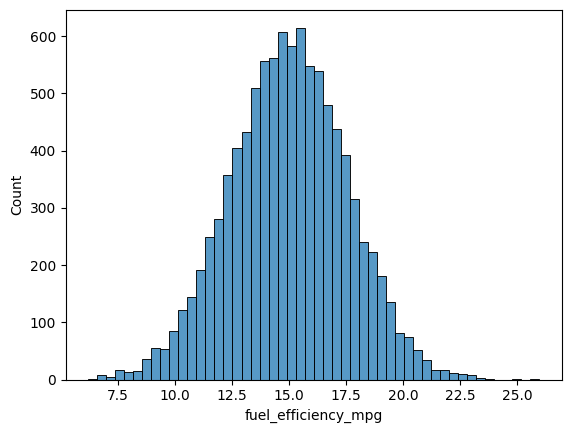

In [4]:
# Plot the horsepower variable:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

### Preparing the dataset 

Preparation:

* Fill missing values with zeros.
* Do train/validation/test split with 60%/20%/20% distribution. 
* Use the `train_test_split` function and set the `random_state` parameter to 1.
* Use `DictVectorizer(sparse=True)` to turn the dataframes into matrices.

In [5]:
df.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object

In [6]:
df.isnull().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [7]:
# Fill missing values with zeros:
df = df.fillna(0.0)

In [8]:
df.isnull().sum()

engine_displacement    0
num_cylinders          0
horsepower             0
vehicle_weight         0
acceleration           0
model_year             0
origin                 0
fuel_type              0
drivetrain             0
num_doors              0
fuel_efficiency_mpg    0
dtype: int64

In [9]:
from sklearn.model_selection import train_test_split

# Do train/validation/test split with 60%/20%/20% distribution and set the random_state parameter to 1:
df_train, df_temp = train_test_split(df, test_size=0.4, random_state=1)
df_test, df_val = train_test_split(df_temp, test_size=0.5, random_state=1)

In [10]:
len(df_train), len(df_val), len(df_test)

(5822, 1941, 1941)

In [11]:
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

In [12]:
y_train = df_train.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']

**`to_dict(orient='records')`** converts Pandas DataFrames into a list of dictionaries, where each dictionary represents a row in the DataFrame. orient='records' converts rows into dictionaries, with column names as keys and row values as values. This is useful for DictVectorizer, which expects input data as a list of dictionaries for one-hot encoding. Each dictionary corresponds to a single data point, making it easy to encode categorical features into numerical representations.

**`sparse=True`** produces a memory-efficient sparse matrix for datasets with many features, e.g. after one-hot encoding categorical variables where the dataset has a large number of zero entries.

**`sparse=False`** produces a dense matrix, which is easier to work with for smaller datasets or when the number of features is manageable. Can be less memory-efficient for large datasets with many zero entries.

In [15]:
# Use DictVectorizer(sparse=True) to turn the dataframes into matrices:
from sklearn.feature_extraction import DictVectorizer
import numpy as np

# Convert the feature data into a list of dictionaries for DictVectorizer
train_dict = df_train.to_dict(orient='records')
val_dict = df_val.to_dict(orient='records')
test_dict = df_test.to_dict(orient='records')

# One-hot encoding
dv = DictVectorizer(sparse=True)

X_train = dv.fit_transform(train_dict)
X_val = dv.transform(val_dict)
X_test = dv.transform(test_dict)

## Question 1

Let's train a decision tree regressor to predict the `fuel_efficiency_mpg` variable. 

* Train a model with `max_depth=1`.


Which feature is used for splitting the data?


* **`'vehicle_weight'`**
* `'model_year'`
* `'origin'`
* `'fuel_type'`

In [19]:
from sklearn.tree import DecisionTreeRegressor, export_text

dtr = DecisionTreeRegressor(max_depth=1)
dtr.fit(X_train, y_train)

print(export_text(dtr, feature_names=list(dv.get_feature_names_out())))

|--- vehicle_weight <= 3028.82
|   |--- value: [16.86]
|--- vehicle_weight >  3028.82
|   |--- value: [12.87]



## Question 2

Train a random forest regressor with these parameters:

* `n_estimators=10`
* `random_state=1`
* `n_jobs=-1` (optional - to make training faster)


What's the RMSE of this model on the validation data?

* 0.045
* **0.45**
* 4.5
* 45.0

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

# n_jobs=-1 tells the model to use all available CPU cores for training
rfr = RandomForestRegressor(n_estimators=10, n_jobs=-1, random_state=1)
rfr.fit(X_train, y_train)

y_pred = rfr.predict(X_val)

rmse = root_mean_squared_error(y_val, y_pred)
print(f"RMSE: {rmse}")

RMSE: 0.45578251485220367


## Question 3

Now let's experiment with the `n_estimators` parameter

* Try different values of this parameter from 10 to 200 with step 10.
* Set `random_state` to `1`.
* Evaluate the model on the validation dataset.


After which value of `n_estimators` does RMSE stop improving?
Consider 3 decimal places for calculating the answer.

- 10
- 25
- 80
- **200**

If it doesn't stop improving, use the latest iteration number in
your answer.

In [22]:
for n in range(10, 201, 10): 
    rfr = RandomForestRegressor(n_estimators=n, random_state=1) 
    rfr.fit(X_train, y_train) 
    y_pred = rfr.predict(X_val) 
    rmse = root_mean_squared_error(y_val, y_pred)

    print(f"n_estimators: {n}, RMSE: {np.round(rmse, 3)}")

n_estimators: 10, RMSE: 0.456
n_estimators: 20, RMSE: 0.444
n_estimators: 30, RMSE: 0.438
n_estimators: 40, RMSE: 0.437
n_estimators: 50, RMSE: 0.436
n_estimators: 60, RMSE: 0.435
n_estimators: 70, RMSE: 0.435
n_estimators: 80, RMSE: 0.435
n_estimators: 90, RMSE: 0.434
n_estimators: 100, RMSE: 0.434
n_estimators: 110, RMSE: 0.434
n_estimators: 120, RMSE: 0.434
n_estimators: 130, RMSE: 0.433
n_estimators: 140, RMSE: 0.433
n_estimators: 150, RMSE: 0.433
n_estimators: 160, RMSE: 0.433
n_estimators: 170, RMSE: 0.432
n_estimators: 180, RMSE: 0.432
n_estimators: 190, RMSE: 0.432
n_estimators: 200, RMSE: 0.432


## Question 4

Let's select the best `max_depth`:

* Try different values of `max_depth`: `[10, 15, 20, 25]`
* For each of these values,
  * try different values of `n_estimators` from 10 till 200 (with step 10)
  * calculate the mean RMSE 
* Fix the random seed: `random_state=1`


What's the best `max_depth`, using the mean RMSE?

* **10**
* 15
* 20
* 25

In [23]:
scores = []
 
for d in [10, 15, 20, 25]:
    for n in range(10, 201, 10): 
        rfr = RandomForestRegressor(n_estimators=n, max_depth=d, random_state=1) 
        rfr.fit(X_train, y_train) 
        y_pred = rfr.predict(X_val) 
        rmse = root_mean_squared_error(y_val, y_pred)
    
        scores.append((n, d, np.round(rmse, 3)))

In [31]:
columns = ['n_estimators', 'max_depth', 'rmse']
df_scores = pd.DataFrame(scores, columns=columns)

In [32]:
df_scores.head()

,n_estimators,max_depth,rmse
0,10,10,0.446
1,20,10,0.438
2,30,10,0.434
3,40,10,0.434
4,50,10,0.434


In [37]:
# Group by max_depth and calculate the mean RMSE for each group
mean_rmse = df_scores.groupby('max_depth')['rmse'].mean()
mean_rmse

max_depth
10    0.43265
15    0.43530
20    0.43550
25    0.43575
Name: rmse, dtype: float64

# Question 5

We can extract feature importance information from tree-based models. 

At each step of the decision tree learning algorithm, it finds the best split. 
When doing it, we can calculate "gain" - the reduction in impurity before and after the split. 
This gain is quite useful in understanding what are the important features for tree-based models.

In Scikit-Learn, tree-based models contain this information in the
[`feature_importances_`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn.ensemble.RandomForestRegressor.feature_importances_)
field. 

For this homework question, we'll find the most important feature:

* Train the model with these parameters:
  * `n_estimators=10`,
  * `max_depth=20`,
  * `random_state=1`,
  * `n_jobs=-1` (optional)
* Get the feature importance information from this model


What's the most important feature (among these 4)? 

* **`vehicle_weight`**
*	`horsepower`
* `acceleration`
* `engine_displacement`	

In [42]:
rfr = RandomForestRegressor(n_estimators=10, max_depth=20, random_state=1, n_jobs=-1)
rfr.fit(X_train, y_train)
feature_importance_dict = dict(zip(dv.get_feature_names_out(), rfr.feature_importances_))
feature_importance_dict

{'acceleration': np.float64(0.011442313735237557),
 'drivetrain=All-wheel drive': np.float64(0.0003428361850955144),
 'drivetrain=Front-wheel drive': np.float64(0.00027678432674605027),
 'engine_displacement': np.float64(0.003159424030350312),
 'fuel_type=Diesel': np.float64(0.00034918888161679113),
 'fuel_type=Gasoline': np.float64(0.0003071871419763815),
 'horsepower': np.float64(0.015933481489766168),
 'model_year': np.float64(0.003066056772754424),
 'num_cylinders': np.float64(0.0023231449140431217),
 'num_doors': np.float64(0.0015756291753787894),
 'origin=Asia': np.float64(0.00043094762405633503),
 'origin=Europe': np.float64(0.00041885303929771223),
 'origin=USA': np.float64(0.0004959383688367859),
 'vehicle_weight': np.float64(0.9598782143148441)}

## Question 6

Now let's train an XGBoost model! For this question, we'll tune the `eta` parameter:

* Install XGBoost
* Create DMatrix for train and validation
* Create a watchlist
* Train a model with these parameters for 100 rounds:

```
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}
```

Now change `eta` from `0.3` to `0.1`.

Which eta leads to the best RMSE score on the validation dataset?

* 0.3
* **0.1**
* Both give equal value

In [43]:
#!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 46.7 MB/s  0:00:02 eta 0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 40.0 MB/s  0:00:06 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]━━━ 1/2 [xgboost]


In [44]:
import xgboost as xgb

features = list(dv.get_feature_names_out())

# Create DMatrix for train and validation
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [49]:
# Create a watchlist
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [53]:
%%capture output

# Train a model with these parameters for 100 rounds
xgb_params = {
    'eta': 0.1, # Test 0.3 and 0.1
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=100, 
                  verbose_eval=5, # Frequency of training logs: Prints evaluation metrics every 5 iterations
                  evals=watchlist)

In [51]:
# Access captured output (%%capture suppresses verbose logs from cluttering the notebook)
s = output.stdout
print(s[:200])

[0]	train-rmse:1.83282	val-rmse:1.85075
[5]	train-rmse:0.51643	val-rmse:0.56127
[10]	train-rmse:0.37400	val-rmse:0.44129
[15]	train-rmse:0.34792	val-rmse:0.43434
[20]	train-rmse:0.33724	val-rmse:0.434


In [52]:
# eta/learning rate = 0.3 
y_pred = model.predict(dval)
eta_03 = root_mean_squared_error(y_val, y_pred)
eta_03

0.45420193807929243

In [54]:
# eta/learning rate = 0.1 
y_pred = model.predict(dval)
eta_01 = root_mean_squared_error(y_val, y_pred)
eta_01

0.428430075669781